# Lab 1: Gaia’s Drifters
### Arina Udalova

In [1]:
# ------------------------------------------------------------------
# Step 1: Import the data and group observations by star
# ------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'serif', 'figure.dpi': 150})

def get_star(data, star_id):
    """Return chronologically sorted observations for one star"""

    # Select only the rows that belong to the requested Gaia source
    mask = data["source_id"] == star_id

    time = data["t_year"][mask]
    magnitude = data["gmag"][mask]
    magnitude_error = data["gmag_err"][mask]

    # Sort chronologically in case the input rows are not already sorted
    order = np.argsort(time)

    return time[order], magnitude[order], magnitude_error[order]

filename = "gaia_m31_lcs.csv"

# dtype=None lets NumPy preserve the large Gaia source IDs as 64-bit integers
data = np.genfromtxt(filename, delimiter=",", names=True, dtype=None, encoding=None)

star_ids = np.unique(data["source_id"])

# Store one dictionary per star so that its measurements and later fit results stay together
star_records = []

for star_id in star_ids:
    time, magnitude, magnitude_error = get_star(data, star_id)
    star_records.append( {
            "source_id": star_id,
            "time": time,
            "magnitude": magnitude,
            "magnitude_error": magnitude_error,
        }
    )

# Inspect the imported data
print("Column names:", data.dtype.names)
print("Number of stars:", len(star_ids))

Column names: ('source_id', 't_year', 'gmag', 'gmag_err')
Number of stars: 2025


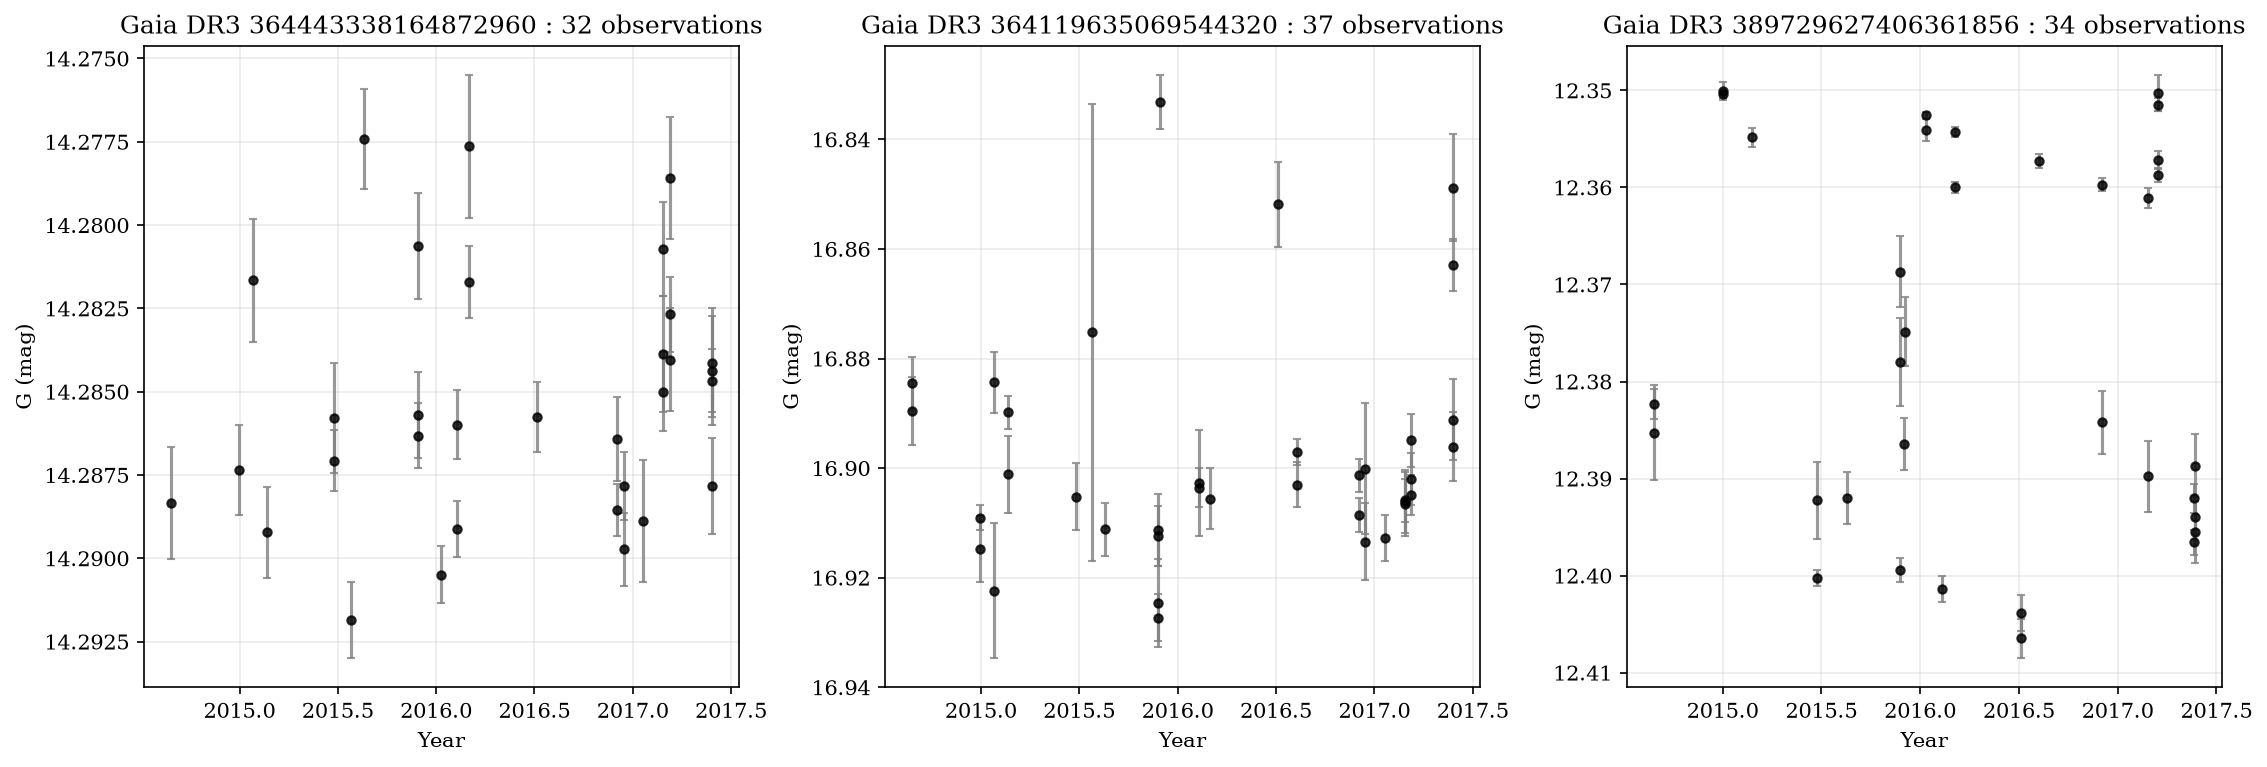

In [2]:
# ------------------------------------------------------------------
# Step 2: Plot three stellar light curves
# ------------------------------------------------------------------

# These are positions in star_records, not the Gaia source_id values themselves
chosen_indices = np.array([30, 5, 1995])

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for ax, star_index in zip(axes, chosen_indices):
    time = star_records[star_index]["time"]
    magnitude = star_records[star_index]["magnitude"]
    magnitude_error = star_records[star_index]["magnitude_error"]

    # Plot measurements with vertical error bars
    ax.errorbar(
        time,
        magnitude,
        yerr=magnitude_error,
        fmt="o",
        color="black",
        ecolor="gray",
        markersize=4,
        capsize=2,
        alpha=0.8
    )

    # Astronomical magnitudes run backward: smaller magnitude is brighter
    ax.invert_yaxis()
    ax.set_xlabel("Year")
    ax.set_ylabel("G (mag)")
    ax.set_title(f"Gaia DR3 {star_records[star_index]["source_id"]} : {len(time)} observations")
    ax.grid(alpha=0.25)

plt.savefig("3_light_curves.png")
plt.show()

Star ID: 364443338164872960
Reference time: 2016.3825993750002
Slope: -0.000628210630381843 mag/year
Magnitude at reference time: 14.285292812500002


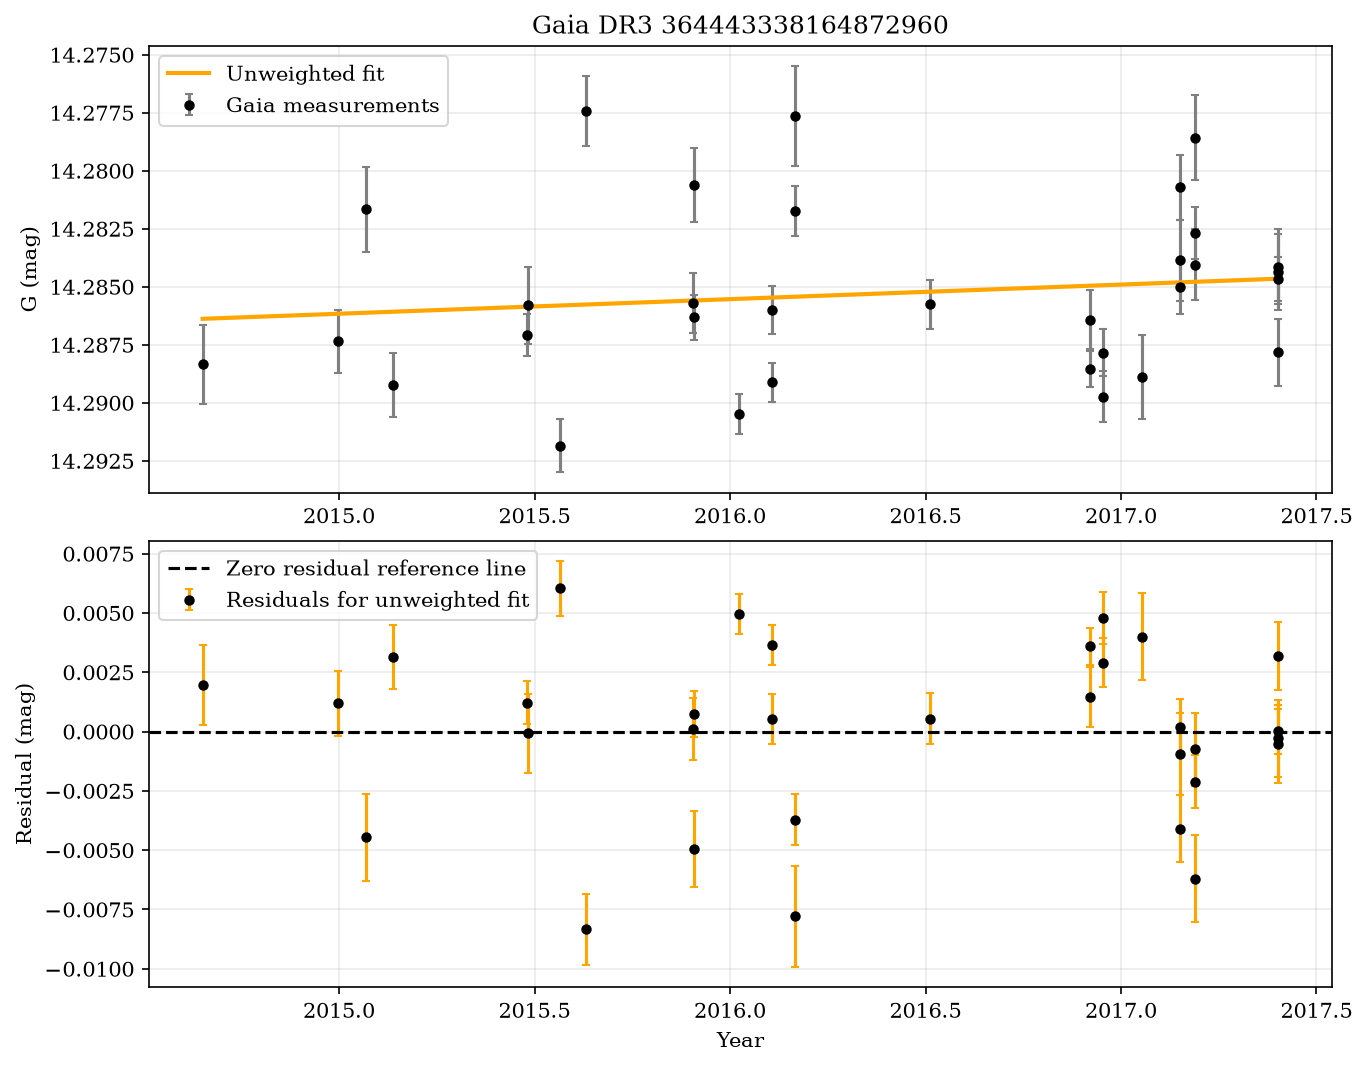

In [3]:
# ------------------------------------------------------------------
# Step 3: Find an unweighted linear fit for one star and residual plot
# ------------------------------------------------------------------

time = star_records[chosen_indices[0]]['time']
magnitude = star_records[chosen_indices[0]]['magnitude']
magnitude_error = star_records[chosen_indices[0]]['magnitude_error']

# Centering leaves the slope unchanged, but makes the intercept the fitted
# magnitude at the mean observation time instead of at the artificial year zero
reference_time = np.mean(time)
centered_time = time - reference_time

# Fit a first-degree polynomial: y = slope*x + intercept
unweighted_coefficients = np.polyfit(centered_time, magnitude, deg=1)
unweighted_slope = unweighted_coefficients[0]
unweighted_intercept = unweighted_coefficients[1]

# Calculate the predicted magnitude at each observation time
model_magnitude = np.polyval(unweighted_coefficients, centered_time)

# Residual = observed magnitude - fitted magnitude 
# Patterns in the residuals would suggest that a straight-line model does not describe the data well
residuals = magnitude - model_magnitude

print("Star ID:", star_records[chosen_indices[0]]['source_id'])
print("Reference time:", reference_time)
print("Slope:", unweighted_slope, "mag/year")
print("Magnitude at reference time:", unweighted_intercept)

fig, axes = plt.subplots(2, 1,figsize=(9, 7), constrained_layout=True)

# Top panel: observations (light curve) and fitted line
axes[0].errorbar(
    time,
    magnitude,
    yerr=magnitude_error,
    fmt="ko",
    ms=4,
    capsize=2,
    ecolor="gray",
    label="Gaia measurements"
)

axes[0].plot(
    time,
    model_magnitude,
    color="orange",
    linewidth=2,
    label="Unweighted fit"
)

axes[0].invert_yaxis()
axes[0].set_ylabel("G (mag)")
axes[0].set_title(f"Gaia DR3 {star_records[chosen_indices[0]]['source_id']}")
axes[0].legend()
axes[0].grid(alpha=0.25)

# Bottom panel: residuals plot
axes[1].errorbar(
    time,
    residuals,
    yerr=magnitude_error,
    fmt="ko",
    ms=4,
    capsize=2,
    ecolor="orange",
    label="Residuals for unweighted fit"
)

# Zero residual reference line
axes[1].axhline(
    0,
    color="black",
    linestyle="--",
    label="Zero residual reference line"
)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Residual (mag)")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.savefig(f"unweighted_fit_and_residuals Gaia DR3 {star_records[chosen_indices[0]]['source_id']}.png")
plt.show()

In [4]:
# ------------------------------------------------------------------
# Step 4: Solve the weighted normal equations
# ------------------------------------------------------------------

# Use the same centered times as in step 3
time = star_records[chosen_indices[0]]['time']
magnitude = star_records[chosen_indices[0]]['magnitude']
magnitude_error = star_records[chosen_indices[0]]['magnitude_error']
reference_time = np.mean(time)
centered_time = time - reference_time

# Construct the design matrix
# Each row is [centered time, 1]
# Its first column multiplies the slope, and its second column multiplies the intercept
X = np.column_stack([centered_time, np.ones_like(centered_time)])

# Weight matrix contains inverse-variance weights: precise measurements influence the fit more
W = np.diag(1 / magnitude_error**2)

# Solve the weighted normal equation (X^T W X)beta = X^T Wy for beta = [slope, intercept] without explicitly taking an inverse
# np.linalg.solve is numerically preferable to explicitly forming a matrix inverse
left_side = X.T @ W @ X
right_side = X.T @ W @ magnitude
normal_coefficients = np.linalg.solve(left_side, right_side)
normal_slope = normal_coefficients[0]
normal_intercept = normal_coefficients[1]

print("Normal-equation slope:", normal_slope)
print("Normal-equation intercept:", normal_intercept)

# np.polyfit uses w=1/sigma because it applies w before squaring residuals
weighted_polyfit_coefficients = np.polyfit(centered_time, magnitude, deg=1, w=1 / magnitude_error)

weighted_polyfit_slope = weighted_polyfit_coefficients[0]
weighted_polyfit_intercept = weighted_polyfit_coefficients[1]

print("Weighted polyfit slope:", weighted_polyfit_slope)
print("Weighted polyfit intercept:", weighted_polyfit_intercept)
print("Coefficient differences:",normal_coefficients - weighted_polyfit_coefficients)
print("Do the results agree?", np.allclose(normal_coefficients, weighted_polyfit_coefficients))

Normal-equation slope: -0.0008294980170283428
Normal-equation intercept: 14.286254899801692
Weighted polyfit slope: -0.0008294980170219182
Weighted polyfit intercept: 14.286254899801689
Coefficient differences: [-6.42465681e-15  3.55271368e-15]
Do the results agree? True


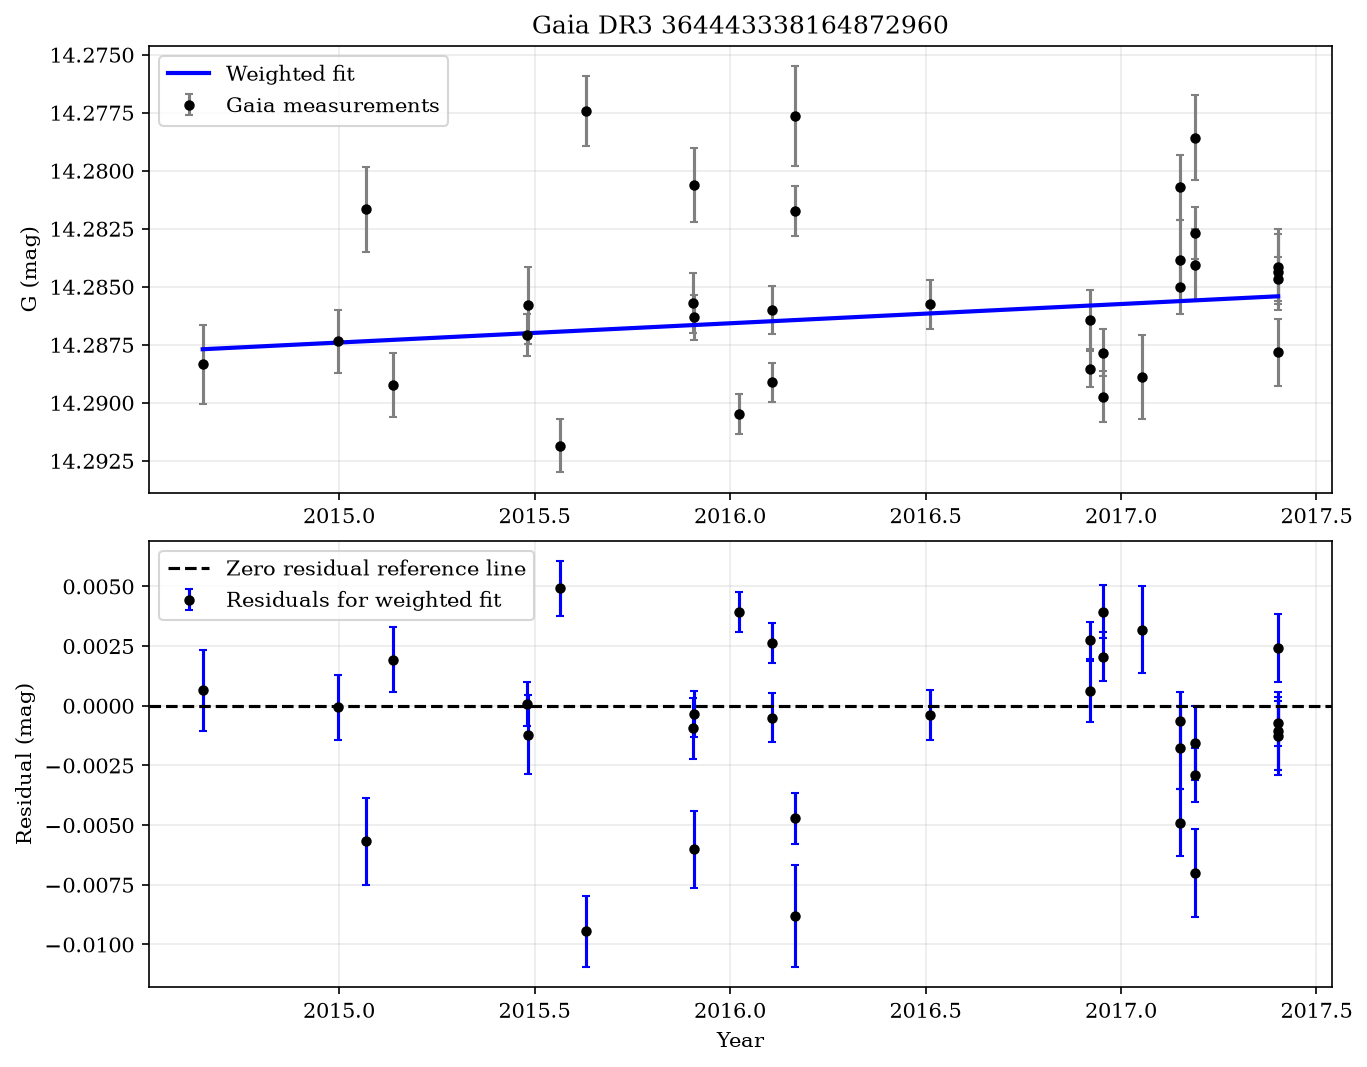

In [5]:
# Top panel: observations (light curve) and weighted fitted line
weighted_model_magnitude = np.polyval(weighted_polyfit_coefficients, centered_time)
weighted_residuals = magnitude - weighted_model_magnitude

fig, axes = plt.subplots(2, 1,figsize=(9, 7), constrained_layout=True)

axes[0].errorbar(
    time,
    magnitude,
    yerr=magnitude_error,
    fmt="ko",
    ms=4,
    capsize=2,
    ecolor="gray",
    label="Gaia measurements"
)

axes[0].plot(
    time,
    weighted_model_magnitude,
    color="blue",
    linewidth=2,
    label="Weighted fit"
)

axes[0].invert_yaxis()
axes[0].set_ylabel("G (mag)")
axes[0].set_title(f"Gaia DR3 {star_records[chosen_indices[0]]['source_id']}")
axes[0].legend()
axes[0].grid(alpha=0.25)

# Bottom panel: weighted residuals plot
axes[1].errorbar(
    time,
    weighted_residuals,
    yerr=magnitude_error,
    fmt="ko",
    ms=4,
    capsize=2,
    ecolor="blue",
    label="Residuals for weighted fit"
)

# Zero residual reference line
axes[1].axhline(
    0,
    color="black",
    linestyle="--",
    label="Zero residual reference line"
)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Residual (mag)")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.savefig(f"weighted_fit_and_residuals Gaia DR3 {star_records[chosen_indices[0]]['source_id']}.png")
plt.show()

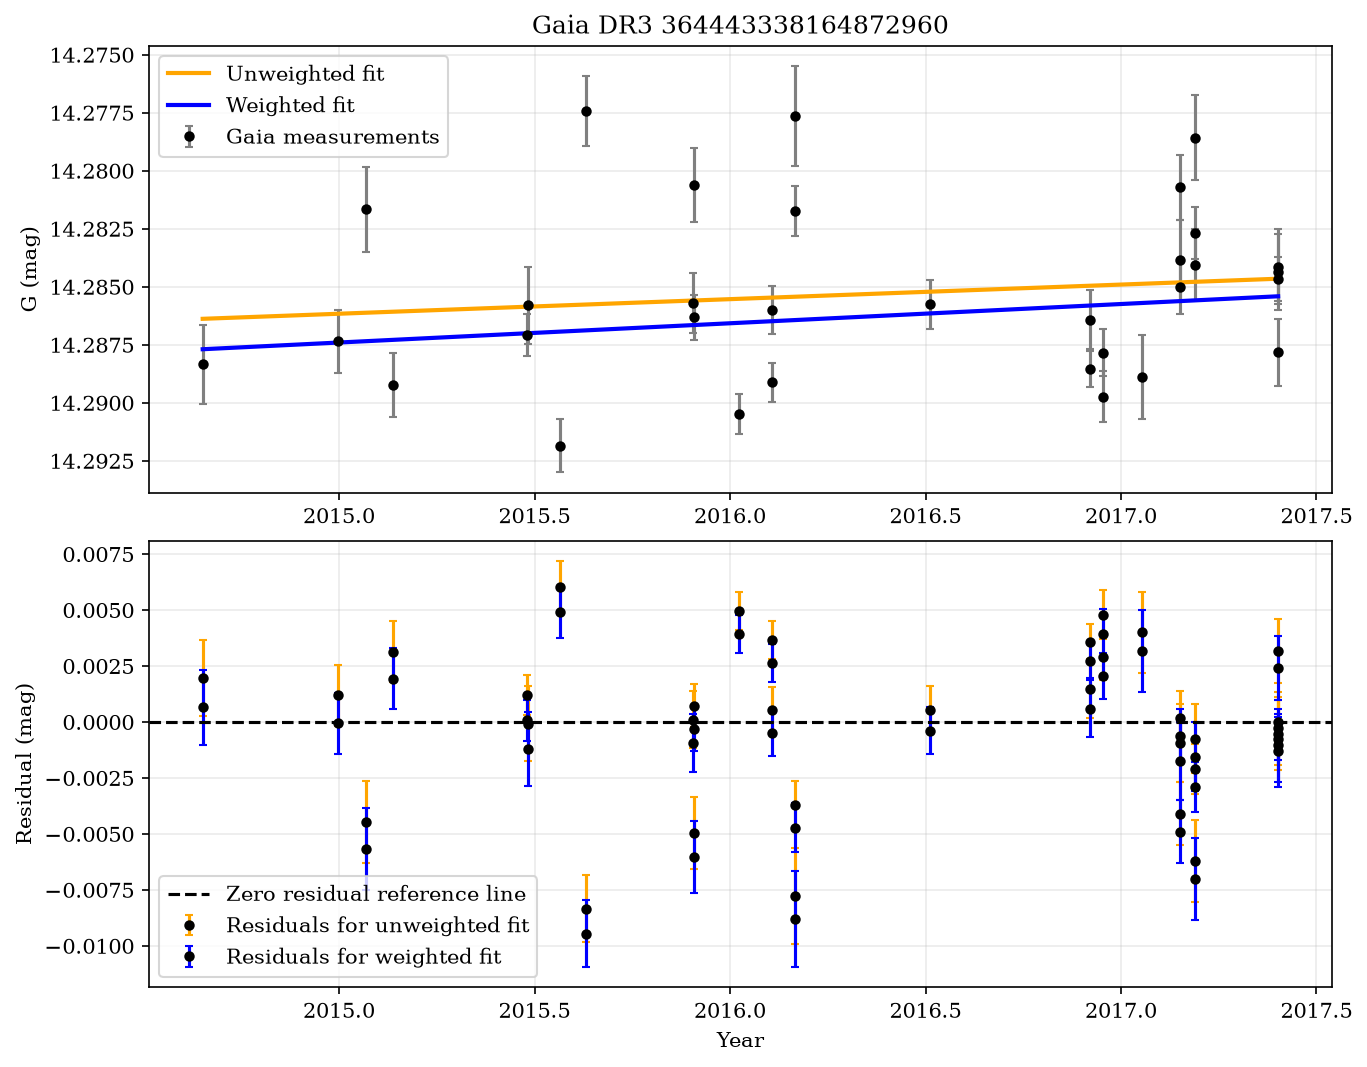

In [6]:
fig, axes = plt.subplots(2, 1,figsize=(9, 7), constrained_layout=True)

axes[0].errorbar(
    time,
    magnitude,
    yerr=magnitude_error,
    fmt="ko",
    ms=4,
    capsize=2,
    ecolor="gray",
    label="Gaia measurements"
)

axes[0].plot(
    time,
    model_magnitude,
    color="orange",
    linewidth=2,
    label="Unweighted fit"
)

axes[0].plot(
    time,
    weighted_model_magnitude,
    color="blue",
    linewidth=2,
    label="Weighted fit"
)

axes[0].invert_yaxis()
axes[0].set_ylabel("G (mag)")
axes[0].set_title(f"Gaia DR3 {star_records[chosen_indices[0]]['source_id']}")
axes[0].legend()
axes[0].grid(alpha=0.25)

# Bottom panel: residuals plot

axes[1].errorbar(
    time,
    residuals,
    yerr=magnitude_error,
    fmt="ko",
    ms=4,
    capsize=2,
    ecolor="orange",
    label="Residuals for unweighted fit"
)

axes[1].errorbar(
    time,
    weighted_residuals,
    yerr=magnitude_error,
    fmt="ko",
    ms=4,
    capsize=2,
    ecolor="blue",
    label="Residuals for weighted fit"
)

# Zero residual reference line
axes[1].axhline(
    0,
    color="black",
    linestyle="--",
    label="Zero residual reference line"
)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Residual (mag)")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.savefig(f"unweighted_and_weighted_fit_and_residuals Gaia DR3 {star_records[chosen_indices[0]]['source_id']}.png")
plt.show()

In [7]:
# ------------------------------------------------------------------
# Step 5: Calculate weighted fit with covariance for every star
# ------------------------------------------------------------------

for record in star_records:
    time = record["time"]
    reference_time = np.mean(time)
    record["reference_time"] = reference_time
    record["centered_time"] = time - reference_time

    # Weighted fit with covariance matrix
    # cov="unscaled" treats the supplied measurement errors as absolute errors, rather than rescaling them using the residual scatter of each fit
    coefficients, covariance = np.polyfit(record["centered_time"], record["magnitude"], deg=1, w=1 / record["magnitude_error"], cov="unscaled")
    record["slope"] = coefficients[0]
    record["intercept"] = coefficients[1]

    # The covariance diagonal contains the variances of slope and intercept
    slope_error, intercept_error = np.sqrt(np.diag(covariance))
    record["slope_error"] = slope_error
    record["intercept_error"] = intercept_error
    record["observation_count"] = len(record["time"])

Mean z: -1.123496584233313
Median z: -1.181369774466813
Standard deviation of z: 29.963441469674358
Number of stars with |z| > 3: 760
84 stars lie outside the displayed range [-20, 20]


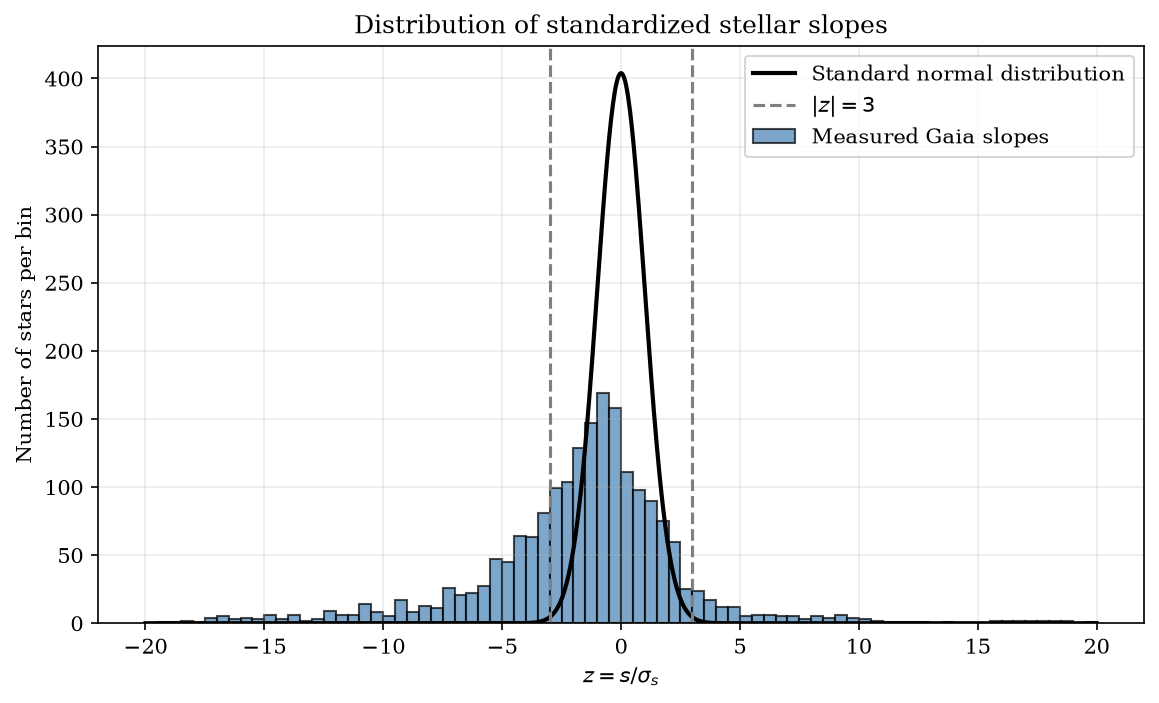

In [8]:
# ------------------------------------------------------------------
# Step 6: Plot histogram of real standardized slopes
# ------------------------------------------------------------------

# z measures how many slope uncertainties the fitted slope is away from zero, where zero slope means no change in magnitude over time
# If there are no real trends and the errors are accurate, z should resemble N(0, 1)
for record in star_records:
    record["z_value"] = record["slope"] / record["slope_error"]

z_values = np.array([record["z_value"] for record in star_records])    

print("Mean z:", np.mean(z_values))
print("Median z:", np.median(z_values))
print("Standard deviation of z:", np.std(z_values, ddof=1))
print("Number of stars with |z| > 3:", np.sum(np.abs(z_values) > 3))

# Select histogram boundaries
z_min = -20
z_max = 20
bins = np.linspace(z_min, z_max, 81)

# Calculate histogram counts
counts, bin_edges = np.histogram(z_values, bins=bins)
bin_width = bin_edges[1] - bin_edges[0]
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate the standard normal probability density
z_grid = np.linspace(z_min, z_max, 1000)
normal_density = (np.exp(-0.5 * z_grid**2) / np.sqrt(2 * np.pi))

# Multiply density by sample size and bin width to obtain expected counts per bin
normal_counts = (normal_density * len(z_values) * bin_width)

# Count values that will not appear in the displayed histogram
number_outside_range = np.sum((z_values < z_min) | (z_values > z_max))

print(f"{number_outside_range} stars lie outside the displayed range [{z_min}, {z_max}]")

fig, ax = plt.subplots(figsize=(9, 5))

# Plot the observed number of stars in each bin
ax.bar(
    bin_centers,
    counts,
    width=bin_width,
    color="steelblue",
    alpha=0.7,
    edgecolor="black",
    label="Measured Gaia slopes"
)
# Plot the expected counts under a standard normal distribution
ax.plot(
    z_grid,
    normal_counts,
    color="black",
    linewidth=2,
    label="Standard normal distribution"
)

ax.axvline(
    -3,
    color="gray",
    linestyle="--",
    label=r"$|z|=3$"
)

ax.axvline(
    3,
    color="gray",
    linestyle="--"
)

ax.set_xlabel(r"$z=s/\sigma_s$")
ax.set_ylabel("Number of stars per bin")
ax.set_title("Distribution of standardized stellar slopes")
ax.legend()
ax.grid(alpha=0.25)
plt.savefig("distribution_of_standardized_slopes.png")
plt.show()

Shuffled mean z: -0.1327730105360699
Shuffled median z: -0.04376149287284325
Shuffled standard deviation of z: 9.429346918147614
Shuffled |z| > 3: 509
Real values outside [-20, 20]: 84
Shuffled values outside [-20, 20]: 45


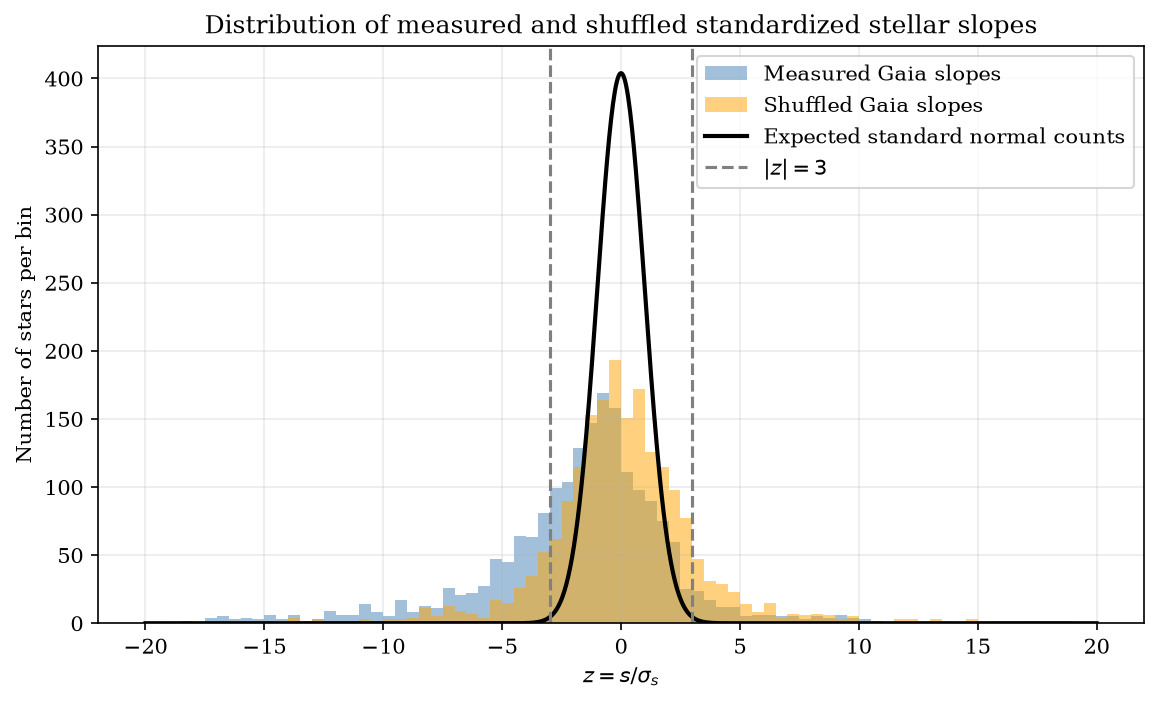

In [9]:
# ------------------------------------------------------------------
# Step 7: Shuffle each star's observations and refit
# ------------------------------------------------------------------

number_of_stars = len(star_ids)

# A fixed seed makes the random shuffle exactly reproducible
rng = np.random.default_rng(42)

shuffled_slopes = np.empty(number_of_stars)
shuffled_slope_errors = np.empty(number_of_stars)
shuffled_z_values = np.empty(number_of_stars)
# Use a list because every star can have a different number of observations
#The saved permutations are reused in step 8 so only the assumed errors change there
permutations = []

for i, record in enumerate(star_records):
    centered_time = record["centered_time"]
    magnitude = record["magnitude"]
    magnitude_error = record["magnitude_error"]

    # Create a random ordering of this star's observations
    permutation = rng.permutation(len(magnitude))
    permutations.append(permutation)

    # Shuffling destroys any real time trend while preserving the observed magnitudes, their uncertainties, and their pairing with each other
    shuffled_magnitude = magnitude[permutation]
    shuffled_magnitude_error = magnitude_error[permutation]

    # Weighted fit to the shuffled measurements
    coefficients, covariance = np.polyfit(centered_time, shuffled_magnitude, deg=1, w=1 / shuffled_magnitude_error, cov="unscaled")

    shuffled_slopes[i] = coefficients[0]
    shuffled_slope_errors[i] = np.sqrt(covariance[0, 0])
    shuffled_z_values[i] = shuffled_slopes[i] / shuffled_slope_errors[i]

print("Shuffled mean z:", np.mean(shuffled_z_values))
print("Shuffled median z:", np.median(shuffled_z_values))
print("Shuffled standard deviation of z:", np.std(shuffled_z_values, ddof=1))
print("Shuffled |z| > 3:", np.sum(np.abs(shuffled_z_values) > 3)) 

# Histogram counts
shuffled_counts, _ = np.histogram(shuffled_z_values, bins=bins)
shuffled_number_outside_range = np.sum((shuffled_z_values < z_min) | (shuffled_z_values > z_max))

print("Real values outside [-20, 20]:", number_outside_range)
print("Shuffled values outside [-20, 20]:", shuffled_number_outside_range)

fig, ax = plt.subplots(figsize=(9, 5))

ax.stairs(
    counts,
    bins,
    color="steelblue",
    fill=True,
    alpha=0.5,
    linewidth=2,
    label="Measured Gaia slopes"
)

ax.stairs(
    shuffled_counts,
    bins,
    color="orange",
    fill=True,
    alpha=0.5,
    linewidth=2,
    label="Shuffled Gaia slopes"
)

ax.plot(
    z_grid,
    normal_counts,
    color="black",
    linewidth=2,
    label="Expected standard normal counts"
)

ax.axvline(
    -3,
    color="gray",
    linestyle="--"
)

ax.axvline(
    3,
    color="gray",
    linestyle="--",
    label=r"$|z|=3$"
)

ax.set_xlabel(r"$z=s/\sigma_s$")
ax.set_ylabel("Number of stars per bin")
ax.set_title("Distribution of measured and shuffled standardized stellar slopes")
ax.legend()
ax.grid(alpha=0.25)
plt.savefig("distribution_of_measured_and_shuffled_standardized_slopes.png")
plt.show()

The measured (z) values are spread out much more than expected. The shuffled  histogram is also much wider than expected. Because shuffling removes any real time dependence, this suggests that the reported photon-noise errors are too small and do not account for all the scatter in the measurements.

Original three-sigma shuffled width: 2.2996492909874484
Number of shuffled values used: 1850
 
Error floor in magnitudes: 0.003149798093363643
Error floor in mmag: 3.1497980933636427
 
Corrected shuffled width: 1.0000000006138805
Shuffled values used for width: 1889
Stars with corrected |z| > 3: 248
Fraction with corrected |z| > 3: 0.12246913580246914


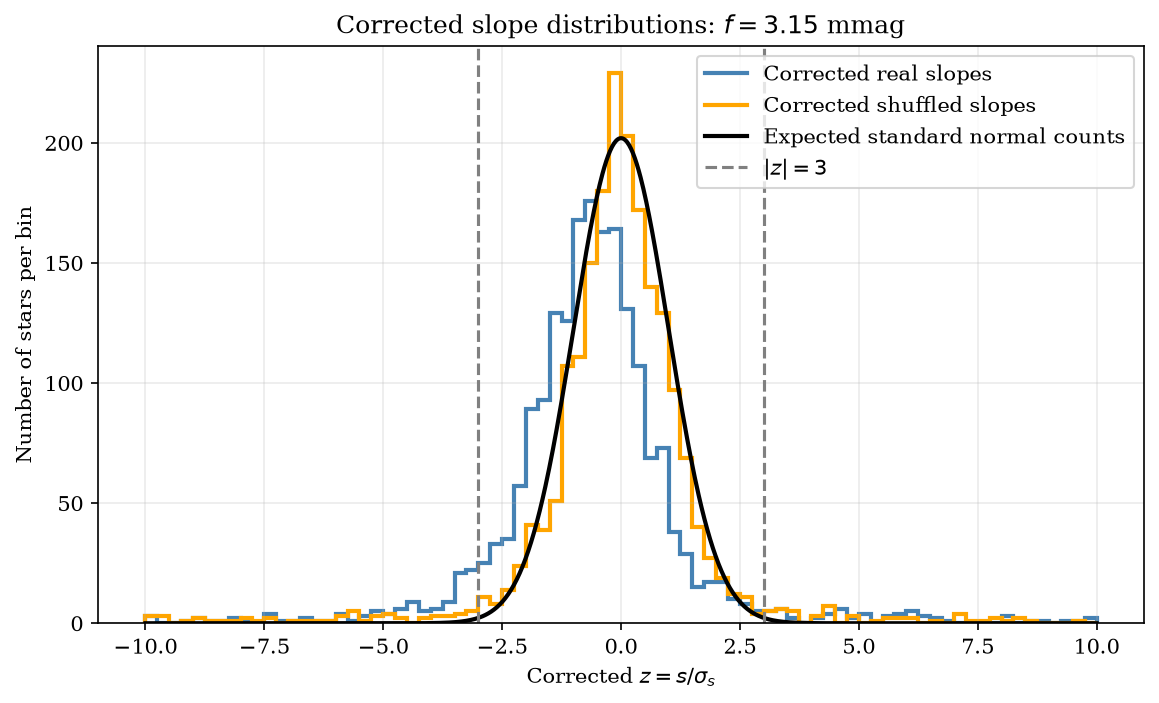

In [10]:
# ------------------------------------------------------------------
# Step 8: Add an error floor and repeat the fits
# ------------------------------------------------------------------

def fit_population(error_floor, shuffled):
    """Fit every star using an additional magnitude error floor"""

    population_slopes = np.empty(number_of_stars)
    population_slope_errors = np.empty(number_of_stars)
    population_z_values = np.empty(number_of_stars)

    for i, record in enumerate(star_records):
        centered_time = record["centered_time"]
        magnitude = record["magnitude"]
        magnitude_error = record["magnitude_error"]

        # Independent uncertainty contributions add in variance (sigma squared), 
        # so combine the reported error and error floor in quadrature
        corrected_error = np.sqrt(magnitude_error**2 + error_floor**2)

        if shuffled:
            # Reuse the exact permutation created in step 7
            permutation = permutations[i]
            fit_magnitude = magnitude[permutation]
            # Keep each magnitude paired with its uncertainty
            fit_error = corrected_error[permutation]
        else:
            fit_magnitude = magnitude
            fit_error = corrected_error

        coefficients, covariance = np.polyfit(centered_time, fit_magnitude, deg=1, w=1 / fit_error, cov="unscaled")

        population_slopes[i] = coefficients[0]
        population_slope_errors[i] = np.sqrt(covariance[0, 0])
        population_z_values[i] = population_slopes[i] / population_slope_errors[i]

    return (population_slopes, population_slope_errors, population_z_values)

def three_sigma_width(z_values):
    """Estimate the central width and calculate the standard deviation after iteratively removing 3-sigma outliers"""
    three_sigma_z_values = z_values.copy()

    for iteration in range(20):
        center = np.mean(three_sigma_z_values)
        width = np.std(three_sigma_z_values, ddof=1)
        keep = (np.abs(three_sigma_z_values - center) < 3 * width)

        # Stop when no additional values are removed
        if np.all(keep):
            break

        three_sigma_z_values = three_sigma_z_values[keep]
    final_width = np.std(three_sigma_z_values, ddof=1)
    return final_width, len(three_sigma_z_values)


original_width, original_count = three_sigma_width(shuffled_z_values)

print("Original three-sigma shuffled width:", original_width)
print("Number of shuffled values used:", original_count)      
print(" ") 

lower_floor = 0.0
upper_floor = 0.020  # 20 mmag

# Repeatedly narrow the interval
# Use bisection to find the error floor that makes the shuffled central width one
# Reusing the same permutations keeps this comparison deterministic
for iteration in range(30):

    trial_floor = (lower_floor + upper_floor) / 2

    _, _, trial_shuffled_z = fit_population(error_floor=trial_floor, shuffled=True)

    trial_width = three_sigma_width(trial_shuffled_z)[0]

    if trial_width > 1: 
        # The z-distribution is still too wide. Errors are still too small. Increase the measurement uncertainties
        lower_floor = trial_floor
    else: 
        # The z-distribution is too narrow. Errors have become too large. Decrease the measurement uncertainties
        upper_floor = trial_floor

error_floor = (lower_floor + upper_floor) / 2

print("Error floor in magnitudes:", error_floor)
print("Error floor in mmag:", error_floor * 1000)
print(" ") 

_, _, corrected_shuffled_z = fit_population(error_floor=error_floor,shuffled=True)

print("Corrected shuffled width:", three_sigma_width(corrected_shuffled_z)[0])
print("Shuffled values used for width:", three_sigma_width(corrected_shuffled_z)[1])

corrected_slopes, corrected_slope_errors, corrected_z_values = (fit_population(error_floor=error_floor, shuffled=False))

for i, record in enumerate(star_records):
    record["corrected_slope"] = (corrected_slopes[i])
    record["corrected_slope_error"] = (corrected_slope_errors[i])
    record["corrected_z_value"] = (corrected_z_values[i])

corrected_significant = np.abs(corrected_z_values) > 3
number_corrected_significant = np.sum(corrected_significant)

print("Stars with corrected |z| > 3:", number_corrected_significant)
print("Fraction with corrected |z| > 3:", number_corrected_significant / len(star_ids))

corrected_z_min = -10
corrected_z_max = 10

corrected_bins = np.linspace(corrected_z_min, corrected_z_max, 81)
corrected_bin_width = (corrected_bins[1] - corrected_bins[0])
corrected_z_grid = np.linspace(corrected_z_min, corrected_z_max, 1000)

corrected_real_counts, _ = np.histogram(corrected_z_values, bins=corrected_bins)
corrected_shuffled_counts, _ = np.histogram(corrected_shuffled_z, bins=corrected_bins)

corrected_normal_density = (np.exp(-0.5 * corrected_z_grid**2) / np.sqrt(2 * np.pi))
corrected_normal_counts = (corrected_normal_density * number_of_stars * corrected_bin_width)

fig, ax = plt.subplots(figsize=(9, 5))

ax.stairs(
    corrected_real_counts,
    corrected_bins,
    color="steelblue",
    linewidth=2,
    label="Corrected real slopes"
)

ax.stairs(
    corrected_shuffled_counts,
    corrected_bins,
    color="orange",
    linewidth=2,
    label="Corrected shuffled slopes"
)

ax.plot(
    corrected_z_grid,
    corrected_normal_counts,
    color="black",
    linewidth=2,
    label="Expected standard normal counts"
)

ax.axvline(
    -3,
    color="gray",
    linestyle="--"
)

ax.axvline(
    3,
    color="gray",
    linestyle="--",
    label=r"$|z|=3$"
)

ax.set_xlabel(r"Corrected $z=s/\sigma_s$")
ax.set_ylabel("Number of stars per bin")
ax.set_title(f"Corrected slope distributions: "f"$f={error_floor * 1000:.2f}$ mmag")
ax.legend()
ax.grid(alpha=0.25)
plt.savefig("corrected_slope_distributions.png")
plt.show()

Here, the width is the standard deviation of the main part of the shuffled (z) distribution. I use three-sigma clipping because the error floor should describe the typical measurement scatter, rather than be determined by a small number of unusual stars or extreme measurements. For a normal distribution, about 99.7% of the values are expected to lie within three standard deviations of the mean, so this cutoff keeps almost all ordinary values while reducing the effect of outliers. I recalculate the mean and standard deviation after each removal and repeat the process until no more values are removed.
The Step 8 histogram only shows (z) values between (-10) and (10) so that the center is easier to see. Values outside this range are still included in the calculations; they are simply not shown in the plot. The number of values outside the range is printed above the graph.

A calibration floor of 3.15 mmag makes the central shuffled distribution have unit width. After applying this correction, 248 stars have \(|z|>3\). These should be described as candidate drifters rather than confirmed astrophysical variables.

Population median slope: -0.0004559558733282547 mag/year
Bootstrap uncertainty: 1.9066781491517613e-05 mag/year
68% bootstrap interval: [-0.00047045 -0.00043928]
95% bootstrap interval: [-0.00049001 -0.0004127 ]
Median divided by uncertainty: -23.913625565547036


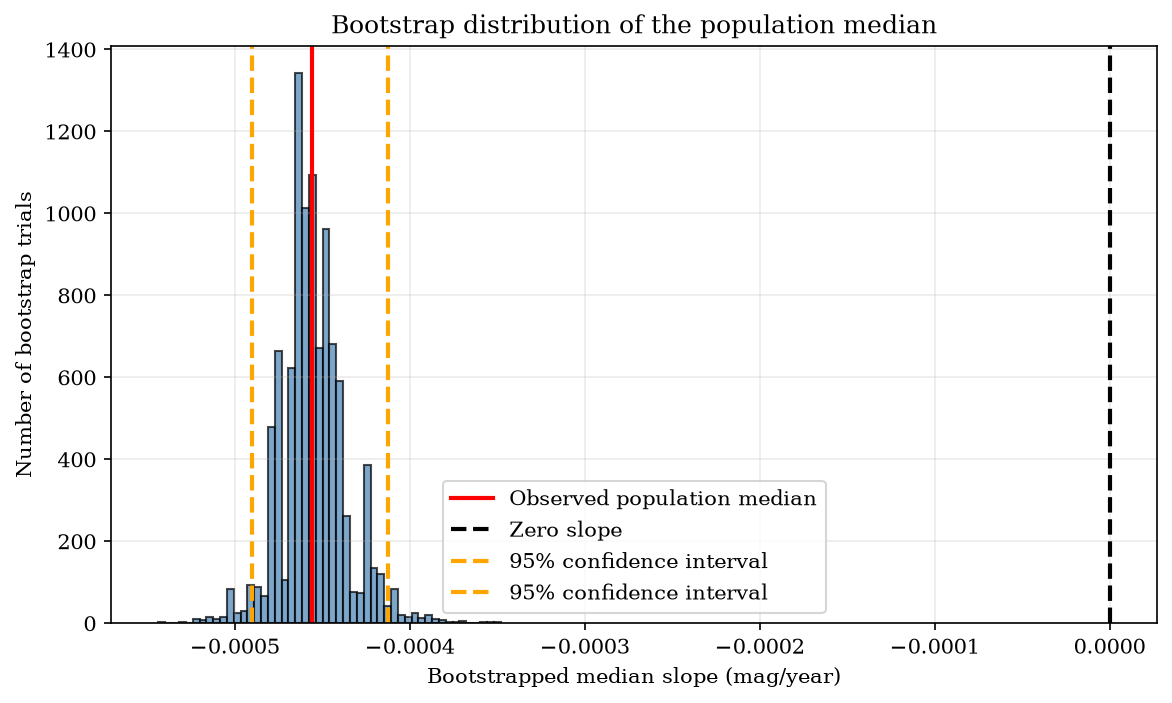

In [11]:
# ------------------------------------------------------------------
# Step 9: Population bias and bootstrap uncertainty
# ------------------------------------------------------------------

population_median_slope = np.median(corrected_slopes)
print("Population median slope:", population_median_slope, "mag/year")

# Bootstrap whole stars because stars, rather than individual measurements,
# are the independent units in this population calculation
bootstrap_rng = np.random.default_rng(12345)
number_of_bootstraps = 10000
bootstrap_medians = np.empty(number_of_bootstraps)

for trial in range(number_of_bootstraps):
    # Draw a new population of the same size with replacement
    # Repeating this approximates the sampling distribution of the population median
    bootstrap_indices = bootstrap_rng.integers(0,number_of_stars, size=number_of_stars)
    bootstrap_sample = corrected_slopes[bootstrap_indices]
    bootstrap_medians[trial] = np.median(bootstrap_sample)

# The spread of bootstrap medians estimates the standard error of the median
median_slope_error = np.std(bootstrap_medians, ddof=1)
confidence_interval_68 = np.percentile(bootstrap_medians, [16, 84])
confidence_interval_95 = np.percentile(bootstrap_medians,[2.5, 97.5])

print("Bootstrap uncertainty:", median_slope_error, "mag/year")
print("68% bootstrap interval:", confidence_interval_68)            
print("95% bootstrap interval:", confidence_interval_95)
print("Median divided by uncertainty:", population_median_slope / median_slope_error)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    bootstrap_medians,
    bins=50,
    color="steelblue",
    edgecolor="black",
    alpha=0.7
)

ax.axvline(
    population_median_slope,
    color="red",
    linewidth=2,
    label="Observed population median"
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Zero slope"
)

ax.axvline(
    confidence_interval_95[0],
    color="orange",
    linestyle="--",
    linewidth=2,
    label="95% confidence interval"
)

ax.axvline(
    confidence_interval_95[1],
    color="orange",
    linestyle="--",
    linewidth=2,
    label="95% confidence interval"
)

ax.set_xlabel("Bootstrapped median slope (mag/year)")
ax.set_ylabel("Number of bootstrap trials")
ax.set_title("Bootstrap distribution of the population median")
ax.legend()
ax.grid(alpha=0.25)
plt.savefig("bootstrap_distribution_of_population_median.png")
plt.show()

In [12]:
# ------------------------------------------------------------------
# Step 9b: Test whether early Gaia epochs cause the population bias
# ------------------------------------------------------------------

late_slopes = np.empty(number_of_stars)

# Use a separate reproducible random stream for this second bootstrap test.
change_bootstrap_rng = np.random.default_rng(67890)

for i, record in enumerate(star_records):

    time = record["time"]
    magnitude = record["magnitude"]
    magnitude_error = record["magnitude_error"]

    # Keep only observations from 2015.5 onward
    late_mask = time >= 2015.5

    late_time = time[late_mask]
    late_magnitude = magnitude[late_mask]
    late_magnitude_error = magnitude_error[late_mask]

    # Apply the error floor found in step 8
    late_corrected_error = np.sqrt(late_magnitude_error**2 + error_floor**2)

    # Recenter the remaining observation times
    late_reference_time = np.mean(late_time)
    late_centered_time = (late_time - late_reference_time)

    late_coefficients = np.polyfit(late_centered_time, late_magnitude, deg=1, w=1 / late_corrected_error)
    late_slopes[i] = late_coefficients[0]

# Population median using observations from 2015.5 onward
late_median_slope = np.median(late_slopes)
# Difference between the late-only and original population medians
observed_median_change = (late_median_slope - population_median_slope)

print("Original median slope:", population_median_slope)
print("Median after excluding t < 2015.5:", late_median_slope)
print("Change in median:", late_median_slope - population_median_slope) 

# Save the late-only median from every bootstrap trial
bootstrap_late_medians = np.empty(number_of_bootstraps)

# Save the difference between the two medians from every trial
bootstrap_median_changes = np.empty(number_of_bootstraps)

# Use identical resampled star indices for both slope arrays
# This paired bootstrap isolates the effect of removing the early observations
for trial in range(number_of_bootstraps):
    # Resample stars with replacement
    bootstrap_indices = change_bootstrap_rng.integers(0, number_of_stars, size=number_of_stars)
    original_sample_median = np.median(corrected_slopes[bootstrap_indices])
    late_sample_median = np.median(late_slopes[bootstrap_indices])
    bootstrap_late_medians[trial] = late_sample_median
    bootstrap_median_changes[trial] = (late_sample_median - original_sample_median)

# The standard deviation of the bootstrapped medians estimates
# the standard error of the late-only median.
late_median_uncertainty = np.std(bootstrap_late_medians, ddof=1)
late_interval_68 = np.percentile(bootstrap_late_medians, [16, 84])
late_interval_95 = np.percentile(bootstrap_late_medians, [2.5, 97.5])

change_uncertainty = np.std(bootstrap_median_changes, ddof=1)
change_interval_95 = np.percentile(bootstrap_median_changes,[2.5, 97.5])

print(f"Original population median: "f"{population_median_slope * 1000:.3f} mmag/year")
print(f"Late-only population median: "f"{late_median_slope * 1000:.3f} "f"+/- {late_median_uncertainty * 1000:.3f} mmag/year")
print("Late-only 68% bootstrap interval:", np.round(late_interval_68 * 1000, 3),"mmag/year")
print("Late-only 95% bootstrap interval:", np.round(late_interval_95 * 1000, 3), "mmag/year")
print(f"Change in population median: "f"{observed_median_change * 1000:+.3f} mmag/year")
print(f"Bootstrap uncertainty of the change: "f"{change_uncertainty * 1000:.3f} mmag/year")
print("Paired 95% interval for the change:", np.round(change_interval_95 * 1000, 3),"mmag/year")

Original median slope: -0.0004559558733282547
Median after excluding t < 2015.5: -0.00044681792923441556
Change in median: 9.13794409383912e-06
Original population median: -0.456 mmag/year
Late-only population median: -0.447 +/- 0.041 mmag/year
Late-only 68% bootstrap interval: [-0.486 -0.401] mmag/year
Late-only 95% bootstrap interval: [-0.53  -0.368] mmag/year
Change in population median: +0.009 mmag/year
Bootstrap uncertainty of the change: 0.036 mmag/year
Paired 95% interval for the change: [-0.063  0.078] mmag/year


The population median is \(-0.456 \pm 0.019\) mmag/year, with a 95% bootstrap interval of \([-0.490,-0.413]\) mmag/year. Although this is statistically different from zero, a shared drift among approximately 2,000 unrelated stars is unlikely to be astrophysical and probably indicates a remaining instrumental error. Removing observations before 2015.5 changes the median by only \(+0.009\) mmag/year, and the confidence interval for this change includes zero. Therefore, the early epochs do not explain the bias.